# Reading Dataset & Processing through NLTK

Followed Rob Mulla's YouTube Tutorial: https://www.youtube.com/watch?v=QpzMWQvxXWk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk

# nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('maxent_ne_chunker_tab')
# nltk.download('words')

## Datasets are taken from: https://amazon-reviews-2023.github.io/

In [2]:
# Read in data
df = pd.read_csv('Data/Video_Games.csv')

# Simply add 1 to the entire index range
df.index = df.index + 1

# This moves the index (0, 1, 2...) into a new column named 'Id'
df.reset_index(inplace=True)
df.rename(columns={'index': 'id'}, inplace=True)

print(df.shape)
df = df.head(500)
print(df.shape)

(4624615, 11)
(500, 11)


In [3]:
df.head()

,id,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1,4,It’s pretty sexual. Not my fav,I’m playing on ps5 and it’s interesting. It’s...,[],B07DJWBYKP,B07DK1H3H5,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2020-12-17 06:33:24.795,0,True
1,2,5,Good. A bit slow,Nostalgic fun. A bit slow. I hope they don’t...,[],B00ZS80PC2,B07SRWRH5D,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2020-04-16 15:31:54.941,1,False
2,3,5,... an order for my kids & they have really en...,This was an order for my kids & they have real...,[],B01FEHJYUU,B07MFMFW34,AGXVBIUFLFGMVLATYXHJYL4A5Q7Q,2017-03-30 12:37:11.000,0,True
3,4,5,Great alt to pro controller,"These work great, They use batteries which is ...",[],B07GXJHRVK,B0BCHWZX95,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,2019-12-29 16:40:34.017,0,True
4,5,5,solid product,I would recommend to anyone looking to add jus...,[],B00HUWA45W,B00HUWA45W,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,2015-03-29 01:18:52.000,0,True


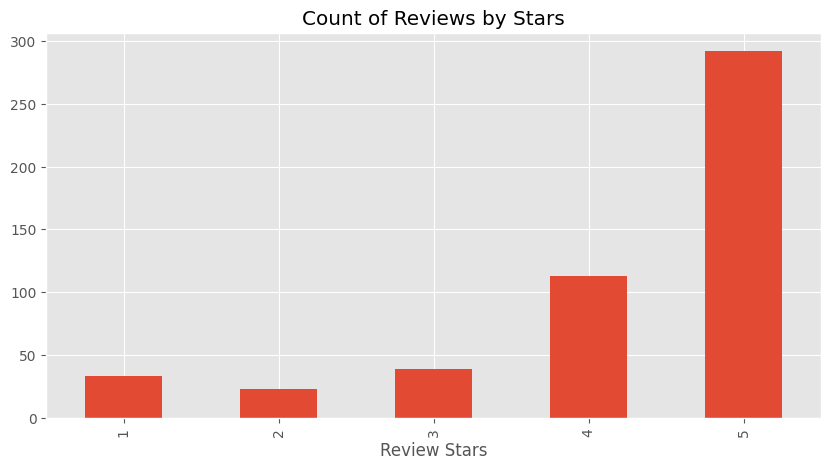

In [4]:
ax = df['rating'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

## Example review

In [5]:
example = df['text'][3]
print(example)

These work great, They use batteries which is a bummer, but for the 40 less that i paid its worth it. Batteries last a long time. Have been using to play rocket league on the switch with no issues


In [6]:
# The text is tokenized, which the text is are split by words stored in a list.
tokens = nltk.word_tokenize(example)
tokens[:10]

['These', 'work', 'great', ',', 'They', 'use', 'batteries', 'which', 'is', 'a']

In [7]:
# NLTK's speech tagger is used to tag each token in the list.
tagged = nltk.pos_tag(tokens)
tagged[:10]

[('These', 'DT'),
 ('work', 'NN'),
 ('great', 'JJ'),
 (',', ','),
 ('They', 'PRP'),
 ('use', 'VBP'),
 ('batteries', 'NNS'),
 ('which', 'WDT'),
 ('is', 'VBZ'),
 ('a', 'DT')]

In [8]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  These/DT
  work/NN
  great/JJ
  ,/,
  They/PRP
  use/VBP
  batteries/NNS
  which/WDT
  is/VBZ
  a/DT
  bummer/NN
  ,/,
  but/CC
  for/IN
  the/DT
  40/CD
  less/JJR
  that/IN
  i/NN
  paid/VBD
  its/PRP$
  worth/NN
  it/PRP
  ./.
  Batteries/NNPS
  last/JJ
  a/DT
  long/JJ
  time/NN
  ./.
  Have/VBP
  been/VBN
  using/VBG
  to/TO
  play/VB
  rocket/NN
  league/NN
  on/IN
  the/DT
  switch/NN
  with/IN
  no/DT
  issues/NNS)


# NLTK's Vader Model

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

# nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

In [10]:
# Positive Statement
sia.polarity_scores('I am so happy!')


{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [11]:
# Negative Statement
sia.polarity_scores('This is the worst thing ever.')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [12]:
# Example review
sia.polarity_scores(example)

{'neg': 0.106, 'neu': 0.711, 'pos': 0.183, 'compound': 0.5267}

In [13]:
# Run the polarity score on the entire dataset
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['text']
    myid = row['id']
    res[myid] = sia.polarity_scores(text)


  0%|          | 0/500 [00:00<?, ?it/s]

In [14]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'id'})
vaders = vaders.merge(df, how='left')

In [15]:
# Now we have sentiment score and metadata
vaders.head()

,id,neg,neu,pos,compound,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1,0.084,0.624,0.292,0.8402,4,It’s pretty sexual. Not my fav,I’m playing on ps5 and it’s interesting. It’s...,[],B07DJWBYKP,B07DK1H3H5,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2020-12-17 06:33:24.795,0,True
1,2,0.000,0.569,0.431,0.8442,5,Good. A bit slow,Nostalgic fun. A bit slow. I hope they don’t...,[],B00ZS80PC2,B07SRWRH5D,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2020-04-16 15:31:54.941,1,False
2,3,0.000,0.696,0.304,0.6880,5,... an order for my kids & they have really en...,This was an order for my kids & they have real...,[],B01FEHJYUU,B07MFMFW34,AGXVBIUFLFGMVLATYXHJYL4A5Q7Q,2017-03-30 12:37:11.000,0,True
3,4,0.106,0.711,0.183,0.5267,5,Great alt to pro controller,"These work great, They use batteries which is ...",[],B07GXJHRVK,B0BCHWZX95,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,2019-12-29 16:40:34.017,0,True
4,5,0.037,0.816,0.147,0.6361,5,solid product,I would recommend to anyone looking to add jus...,[],B00HUWA45W,B00HUWA45W,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,2015-03-29 01:18:52.000,0,True


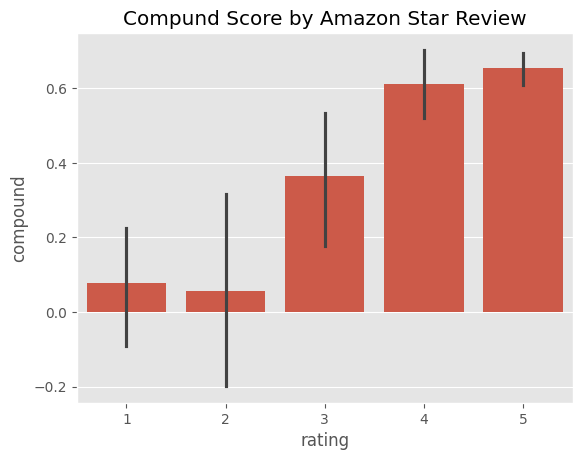

In [16]:
ax = sns.barplot(data=vaders, x='rating', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

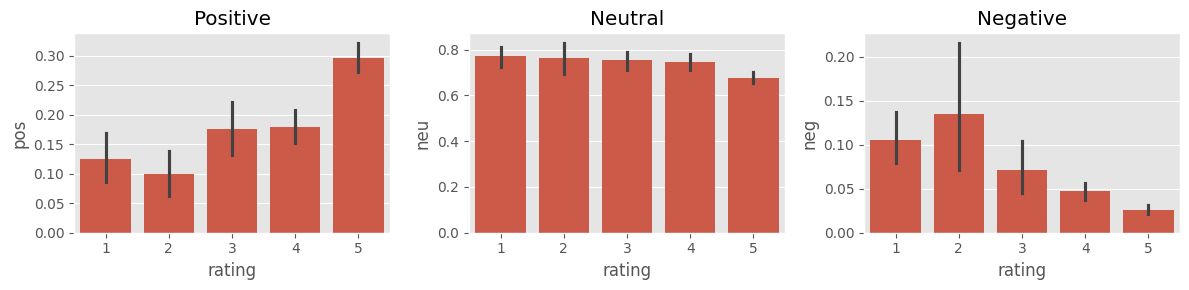

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='rating', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='rating', y='neg', ax=axs[2])
sns.barplot(data=vaders, x='rating', y='neu', ax=axs[1])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

# Hugging Face's Roberta Model

In [18]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [19]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [20]:
# VADER results on example
print(example)
sia.polarity_scores(example)

These work great, They use batteries which is a bummer, but for the 40 less that i paid its worth it. Batteries last a long time. Have been using to play rocket league on the switch with no issues


{'neg': 0.106, 'neu': 0.711, 'pos': 0.183, 'compound': 0.5267}

In [21]:
# Run for Roberta Model
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)


{'roberta_neg': np.float32(0.011555314), 'roberta_neu': np.float32(0.06272576), 'roberta_pos': np.float32(0.92571896)}


In [22]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict



In [24]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['text']
        myid = row['id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')



  0%|          | 0/500 [00:00<?, ?it/s]

Broke for id 93
Broke for id 95
Broke for id 96
Broke for id 97
Broke for id 98
Broke for id 99
Broke for id 100
Broke for id 101
Broke for id 102
Broke for id 103
Broke for id 105
Broke for id 106
Broke for id 107
Broke for id 108
Broke for id 109
Broke for id 110
Broke for id 111
Broke for id 113
Broke for id 114
Broke for id 115
Broke for id 116
Broke for id 117
Broke for id 118
Broke for id 120
Broke for id 121
Broke for id 122
Broke for id 124
Broke for id 126
Broke for id 127
Broke for id 128
Broke for id 131
Broke for id 132
Broke for id 133
Broke for id 137
Broke for id 138
Broke for id 213
Broke for id 357
Broke for id 404
Broke for id 405
Broke for id 406


In [26]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'id'})
results_df = results_df.merge(df, how='left')

In [27]:
results_df.columns

Index(['id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'rating', 'title', 'text',
       'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote',
       'verified_purchase'],
      dtype='str')

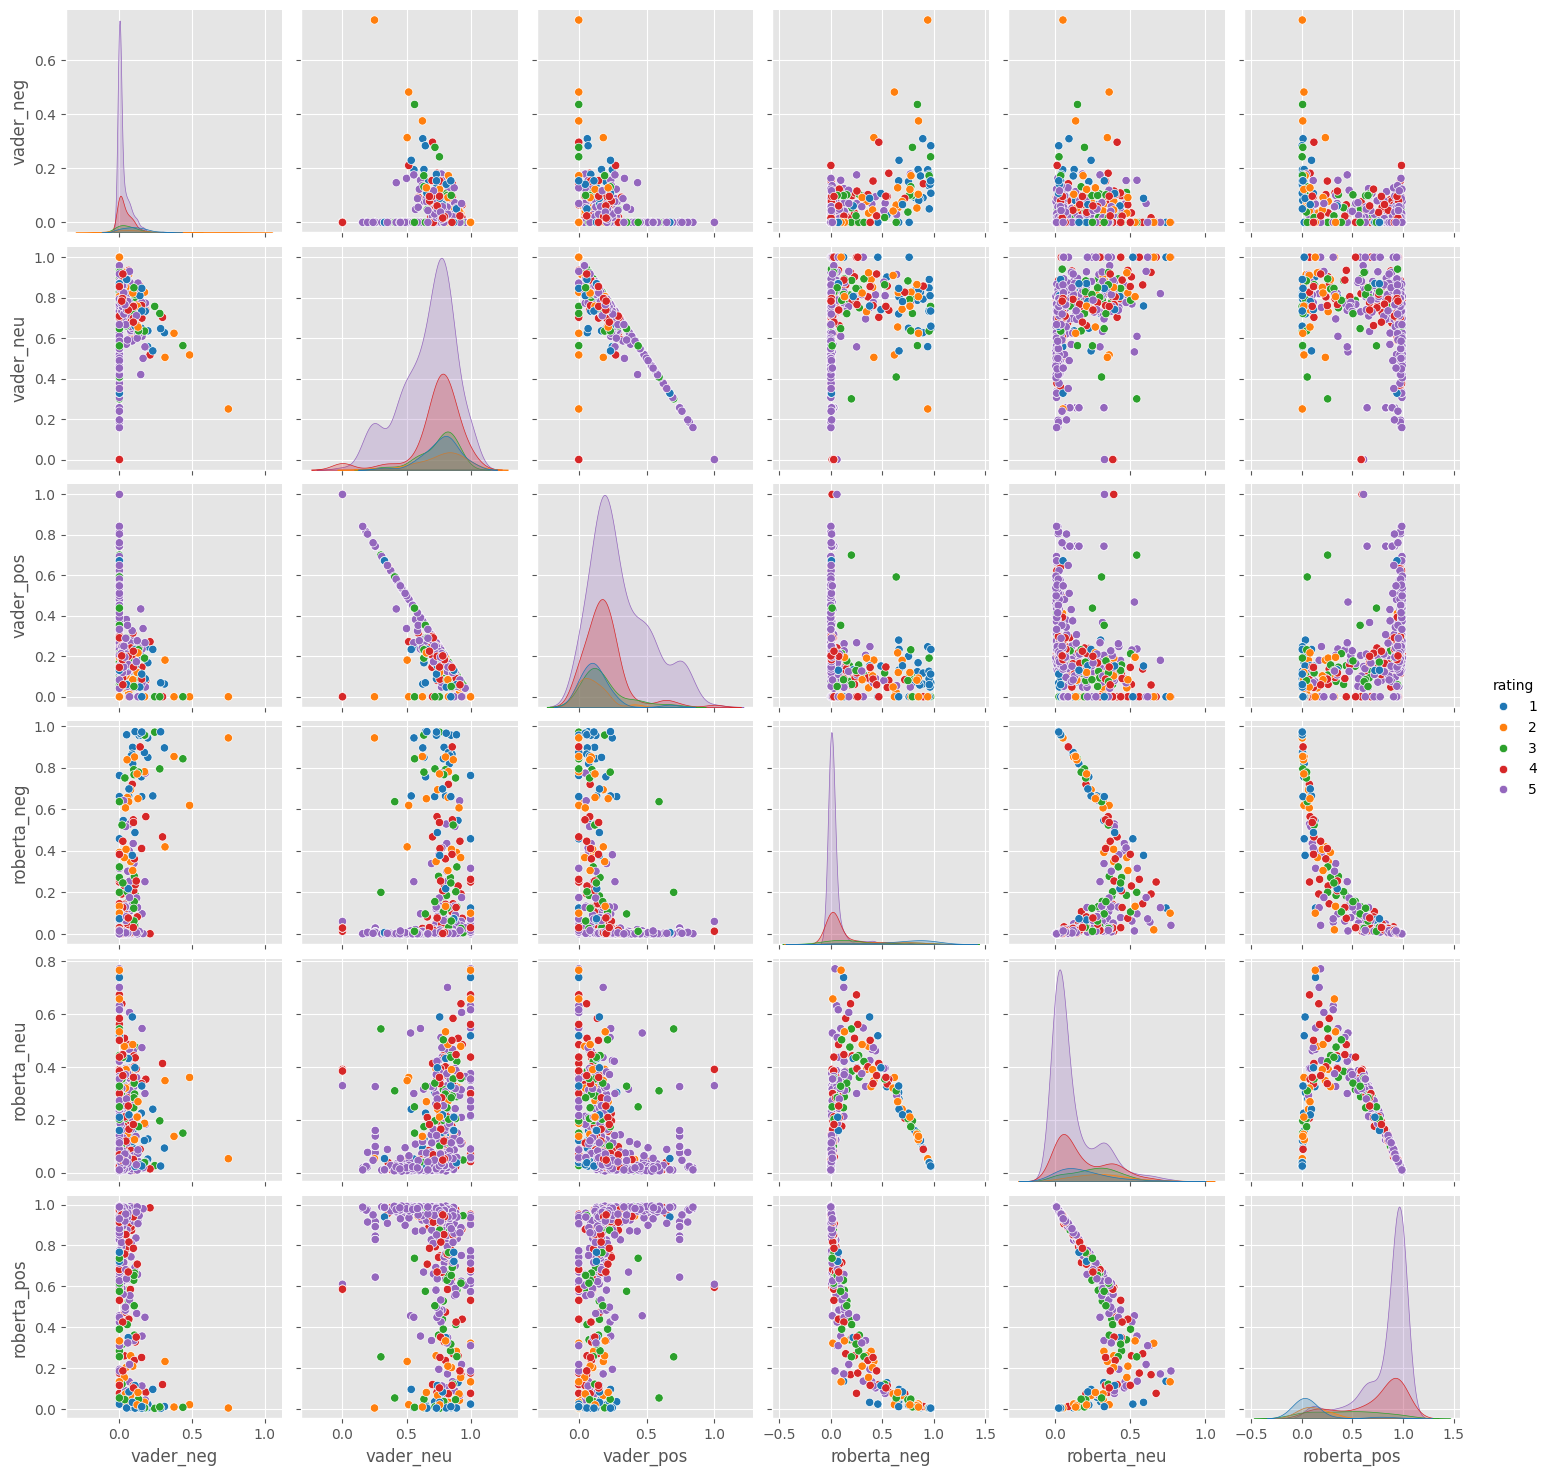

In [30]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='rating',
            palette='tab10')
plt.show()